# Rayleigh Waves Theory

 > **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/05a_Rayleigh_Waves.ipynb)

**Learning Objectives:**
- Derive the Rayleigh wave equation in a half-space
- Understand retrograde elliptical particle motion
- Analyze dispersion characteristics
- Visualize depth sensitivity kernels

**Prerequisites:** Potential theory, Boundary value problems

**Reference:** Shearer, Chapter 8 (Surface Waves)

**Notebook Outline:**
- [0. Setup: parameters and nondimensionalization](#0-Setup-parameters-and-nondimensionalization)
- [1. Eigenvalue problem: solve the Rayleigh equation](#1-Eigenvalue-problem-solve-the-Rayleigh-equation)
- [2. Eigenfunctions: depth dependence of ux(z), uz(z)](#2-Eigenfunctions-depth-dependence-of-uxz,-uzz)
- [3. Particle motion](#3-Particle-motion)
- [4. Sensitivity experiment](#4-Sensitivity-experiment)

---
This section designs a self-contained Python notebook that students build during or immediately after the Rayleigh-wave lecture. The goal is not numerical sophistication, but conceptual translation between:



In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
from scipy.optimize import brentq # https://mathworld.wolfram.com/BrentsMethod.html



## 0. Setup: parameters and nondimensionalization
- Choose β (shear speed), ν (Poisson ratio) or α/β.
- Work with nondimensional phase velocity x = c/β.

In [2]:
beta = 3.5  # km/s (can be arbitrary scale)
nu = 0.25   # Poisson ratio (try 0.20, 0.25, 0.30, 0.33)

# From isotropic elasticity: alpha/beta = sqrt((2(1-nu))/(1-2nu))
alpha_over_beta = np.sqrt(2*(1 - nu) / (1 - 2*nu))
alpha = alpha_over_beta * beta

print(f"alpha/beta = {alpha_over_beta:.4f}")

alpha/beta = 1.7321


## 1. Eigenvalue problem: solve the Rayleigh equation
- Implement Rayleigh function F(x; α/β) = 0.
- Root-find x in (0, 1).

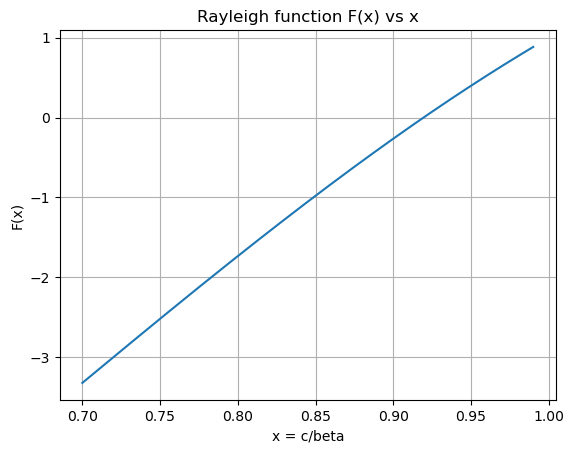

In [3]:
# We'll solve in terms of x = c/beta in (0, 1)
# Define kappa = (beta/alpha)^2
kappa = (beta/alpha)**2

def rayleigh_F(x, kappa):
    """
    Rayleigh equation in a common dimensionless form:
      F(x) = x^6 - 8 x^4 + 8(3 - 2 kappa) x^2 - 16(1 - kappa) = 0
    where x = c/beta, kappa = (beta/alpha)^2.
    """
    x2 = x*x
    return x2**3 - 8*x2**2 + 8*(3 - 2*kappa)*x2 - 16*(1 - kappa)
plt.plot(np.linspace(0.7, 0.99, 200), [rayleigh_F(x, kappa) for x in np.linspace(0.7, 0.99, 200)])
plt.xlabel("x = c/beta")
plt.ylabel("F(x)")
plt.title("Rayleigh function F(x) vs x")
plt.grid(True)
plt.show()

In [4]:

# Root bracket: Rayleigh x typically ~0.87-0.96 depending on nu.
# A safe bracket is (0.7, 0.99)
xR = brentq(rayleigh_F, 0.7, 0.99, args=(kappa,))
cR = xR * beta

print(f"Rayleigh x = cR/beta = {xR:.6f}")
print(f"Rayleigh cR = {cR:.6f} km/s")

Rayleigh x = cR/beta = 0.919402
Rayleigh cR = 3.217906 km/s


## 2. Eigenfunctions: depth dependence of ux(z), uz(z)
- Compute evanescence coefficients qα, qβ.
- Choose amplitude ratio from boundary conditions (up to an arbitrary constant).
- Plot normalized ux(z), uz(z).

For a plane wave $exp(i(kx - wt))$ with $c = w/k$, define:

$$ q_{\alpha} = \sqrt(1 - (c/\alpha)^2), q_{\beta} = \sqrt(1 - (c/\beta)^2) $$

These control exponential decay with depth: $exp(-k q z)$

In [5]:
x = xR
q_beta = np.sqrt(1 - x**2)                       # since x=c/beta
q_alpha = np.sqrt(1 - (x/alpha_over_beta)**2)    # since c/alpha = (x beta)/(alpha) = x/(alpha/beta)

# Choose wavelength to nondimensionalize depth: z' = z / lambda
# k = 2pi / lambda, so k z = 2pi (z/lambda)
lam = 1.0          # nondimensional wavelength unit
k = 2*np.pi/lam

z_over_lam = np.linspace(0, 1.5, 600)  # depth from 0 to 1.5 wavelengths
z = z_over_lam * lam


Amplitude ratio between potentials (A and B) from **traction-free BCs**. A full derivation yields a linear system; any non-trivial solution defines ratio.

We can enforce one boundary condition to define ratio and still get the correct shape.
 A commonly used ratio (up to scaling) is:

$$   B/A = - 2 q_{\alpha} / (1 + q_{\beta}^2) $$
 
 This captures the essential phase relation and nodal behavior for $u_x$.


In [6]:

B_over_A = - (2*q_alpha) / (1 + q_beta**2)


Potentials (omit time and x dependence; keep depth dependence only):
$$ \phi ~ A \exp(-k q_{\alpha} z), \psi ~ B exp(-k q_{\beta} z)$$

Displacements for Rayleigh wave:
$$ u_x = d\phi/dx - d\psi/dz \to (k A) \exp(-k q_{\alpha} z) + (k q_{\beta} B) \exp(-k q_{\beta} z) $$

$$ u_z = d\phi/dz + d\psi/dx  \to -(k q_{\alpha} A) \exp(-k q_{\alpha} z) + (k B) \exp(-k q_{\beta} z) $$

 We'll drop the common factor k and set A=1 for shape.

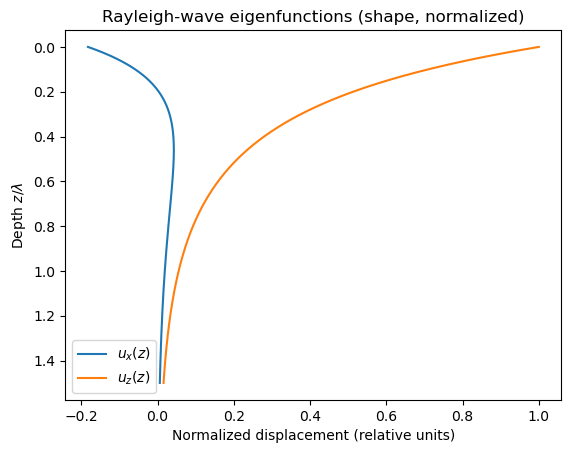

In [7]:


A = 1.0
B = B_over_A * A

ux = (A * np.exp(-k*q_alpha*z)) + (q_beta * B * np.exp(-k*q_beta*z))
uz = (-q_alpha * A * np.exp(-k*q_alpha*z)) + (B * np.exp(-k*q_beta*z))

# Normalize so surface vertical displacement = 1
ux /= uz[0]
uz /= uz[0]

# Plot eigenfunctions
plt.figure()
plt.plot(ux, z_over_lam, label=r"$u_x(z)$")
plt.plot(uz, z_over_lam, label=r"$u_z(z)$")
plt.gca().invert_yaxis()
plt.xlabel("Normalized displacement (relative units)")
plt.ylabel(r"Depth $z/\lambda$")
plt.title("Rayleigh-wave eigenfunctions (shape, normalized)")
plt.legend()
plt.show()

## 3. Particle motion
- At fixed x, build ux(t), uz(t) at selected depths.
- Plot ellipses; identify retrograde vs prograde and the depth of sign change in ux.

Build time dependence: cos(ωt) and sin(ωt) phase shift.
 Rayleigh motion has a ~90° phase offset between ux and uz.
We'll use:
$$  u_z(t) = uz(z) * cos(\omega t) $$
$$   u_x(t) = ux(z) * sin(\omega t) $$

 which produces an ellipse.


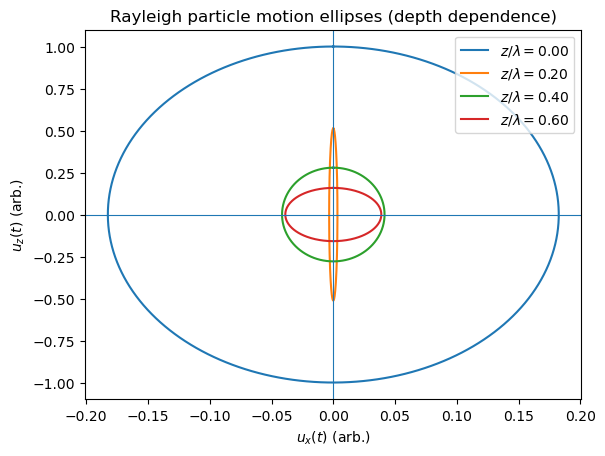

In [8]:

t = np.linspace(0, 2*np.pi, 400)

depths = [0.0, 0.2, 0.4, 0.6]  # in z/lambda
plt.figure()
for d in depths:
    idx = np.argmin(np.abs(z_over_lam - d))
    x_traj = ux[idx] * np.sin(t)
    z_traj = uz[idx] * np.cos(t)
    plt.plot(x_traj, z_traj, label=fr"$z/\lambda={z_over_lam[idx]:.2f}$")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
# plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel(r"$u_x(t)$ (arb.)")
plt.ylabel(r"$u_z(t)$ (arb.)")
plt.title("Rayleigh particle motion ellipses (depth dependence)")
plt.legend()
plt.show()

## 4. Sensitivity experiment
- Vary ν; re-solve cR; observe change in eigenfunctions.


In [9]:
sign_change_indices = np.where(np.sign(ux[:-1]) != np.sign(ux[1:]))[0]
if len(sign_change_indices) > 0:
    idx0 = sign_change_indices[0]
    print(f"ux changes sign near z/lambda ≈ {z_over_lam[idx0]:.3f} to {z_over_lam[idx0+1]:.3f}")
else:
    print("No sign change in ux found in plotted depth range.")


ux changes sign near z/lambda ≈ 0.190 to 0.193
